In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# Configuration
DATA_FILE = "/home/lucas_takanori/phd/data/subject001_baseline_masked.h5"  # Change this to your data file path
plt.style.use('default')  # Use default matplotlib style


In [2]:
# Load and examine data structure
def load_data_info(data_file):
    """Load and display basic information about the data file"""
    with h5py.File(data_file, 'r') as f:
        # Get PVI data
        pvi_data = f['data']['pviHP']['img'][:]
        bp_data = f['data']['bp']['signal'][:]
        
        print(f"Data file: {os.path.basename(data_file)}")
        print(f"PVI data shape: {pvi_data.shape}  # [batch, height, width, frames]")
        print(f"BP data shape: {bp_data.shape}    # [batch, frames]")
        print(f"PVI data range: [{pvi_data.min():.3f}, {pvi_data.max():.3f}]")
        print(f"BP data range: [{bp_data.min():.1f}, {bp_data.max():.1f}] mmHg")
        
        return pvi_data, bp_data

# Load the data
pvi_data, bp_data = load_data_info(DATA_FILE)


Data file: subject001_baseline_masked.h5
PVI data shape: (50, 32, 32, 867)  # [batch, height, width, frames]
BP data shape: (50, 867)    # [batch, frames]
PVI data range: [nan, nan]
BP data range: [39.4, 131.0] mmHg


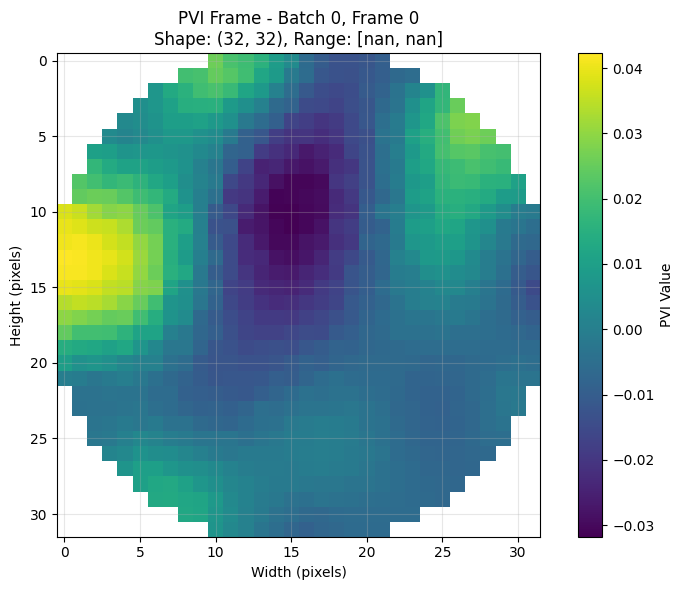

In [3]:
def plot_single_frame(pvi_data, batch_idx=0, frame_idx=0, figsize=(8, 6)):
    """Plot a single PVI frame"""
    
    # Extract the frame
    frame = pvi_data[batch_idx, :, :, frame_idx]
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Plot the frame
    im = plt.imshow(frame, cmap='viridis', aspect='equal')
    plt.colorbar(im, label='PVI Value')
    plt.title(f'PVI Frame - Batch {batch_idx}, Frame {frame_idx}\nShape: {frame.shape}, Range: [{frame.min():.3f}, {frame.max():.3f}]')
    plt.xlabel('Width (pixels)')
    plt.ylabel('Height (pixels)')
    
    # Add grid for better visualization
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return frame

# Plot first frame
frame = plot_single_frame(pvi_data, batch_idx=0, frame_idx=0)


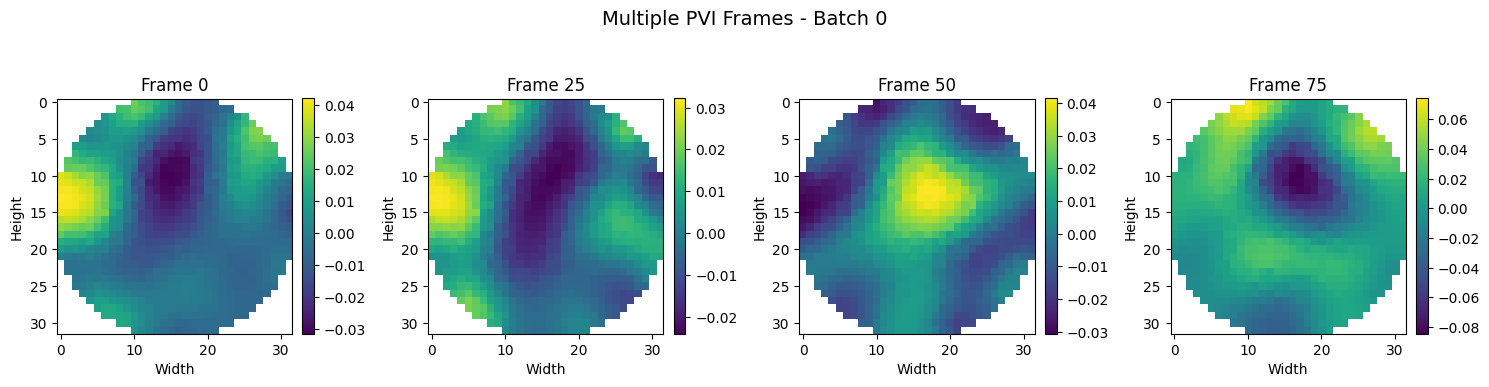

In [4]:
def plot_multiple_frames(pvi_data, batch_idx=0, frame_indices=[0, 10, 20, 30], figsize=(15, 4)):
    """Plot multiple frames from the same batch"""
    
    n_frames = len(frame_indices)
    fig, axes = plt.subplots(1, n_frames, figsize=figsize)
    
    if n_frames == 1:
        axes = [axes]
    
    for i, frame_idx in enumerate(frame_indices):
        if frame_idx < pvi_data.shape[3]:  # Check if frame exists
            frame = pvi_data[batch_idx, :, :, frame_idx]
            
            im = axes[i].imshow(frame, cmap='viridis', aspect='equal')
            axes[i].set_title(f'Frame {frame_idx}')
            axes[i].set_xlabel('Width')
            axes[i].set_ylabel('Height')
            
            # Add colorbar to each subplot
            plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
        else:
            axes[i].text(0.5, 0.5, f'Frame {frame_idx}\nnot available', 
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_xticks([])
            axes[i].set_yticks([])
    
    plt.suptitle(f'Multiple PVI Frames - Batch {batch_idx}', fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot multiple frames
plot_multiple_frames(pvi_data, batch_idx=0, frame_indices=[0, 25, 50, 75])


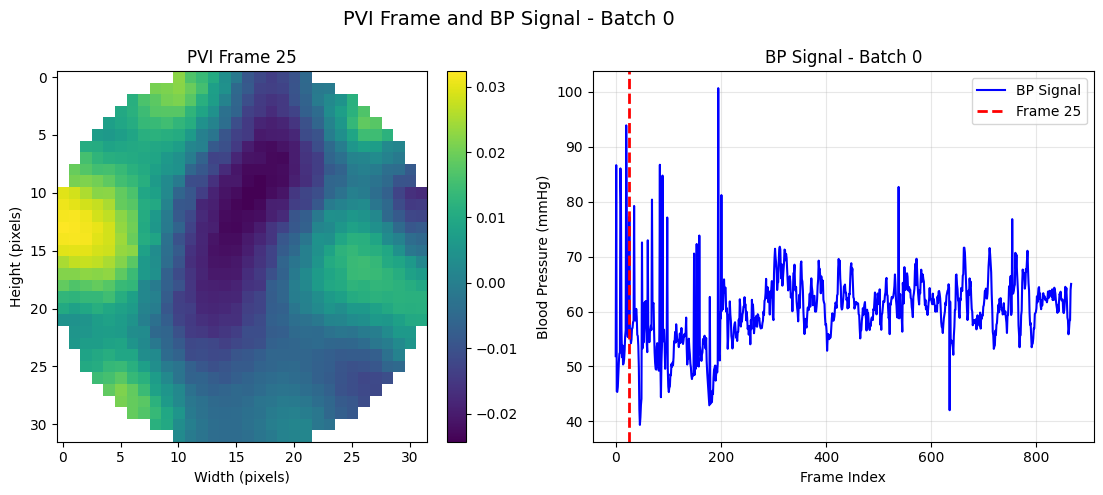

Frame value range: [nan, nan]
BP at frame 25: 57.0 mmHg


In [5]:
def plot_frame_with_bp(pvi_data, bp_data, batch_idx=0, frame_idx=25, figsize=(12, 5)):
    """Plot a PVI frame alongside the corresponding BP signal"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot PVI frame
    frame = pvi_data[batch_idx, :, :, frame_idx]
    im = ax1.imshow(frame, cmap='viridis', aspect='equal')
    ax1.set_title(f'PVI Frame {frame_idx}')
    ax1.set_xlabel('Width (pixels)')
    ax1.set_ylabel('Height (pixels)')
    plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
    
    # Plot BP signal with frame indicator
    bp_signal = bp_data[batch_idx, :]
    time_points = np.arange(len(bp_signal))
    
    ax2.plot(time_points, bp_signal, 'b-', linewidth=1.5, label='BP Signal')
    ax2.axvline(x=frame_idx, color='red', linestyle='--', linewidth=2, label=f'Frame {frame_idx}')
    ax2.set_title(f'BP Signal - Batch {batch_idx}')
    ax2.set_xlabel('Frame Index')
    ax2.set_ylabel('Blood Pressure (mmHg)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.suptitle(f'PVI Frame and BP Signal - Batch {batch_idx}', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"Frame value range: [{frame.min():.3f}, {frame.max():.3f}]")
    print(f"BP at frame {frame_idx}: {bp_signal[frame_idx]:.1f} mmHg")

# Plot frame with BP context
plot_frame_with_bp(pvi_data, bp_data, batch_idx=0, frame_idx=25)


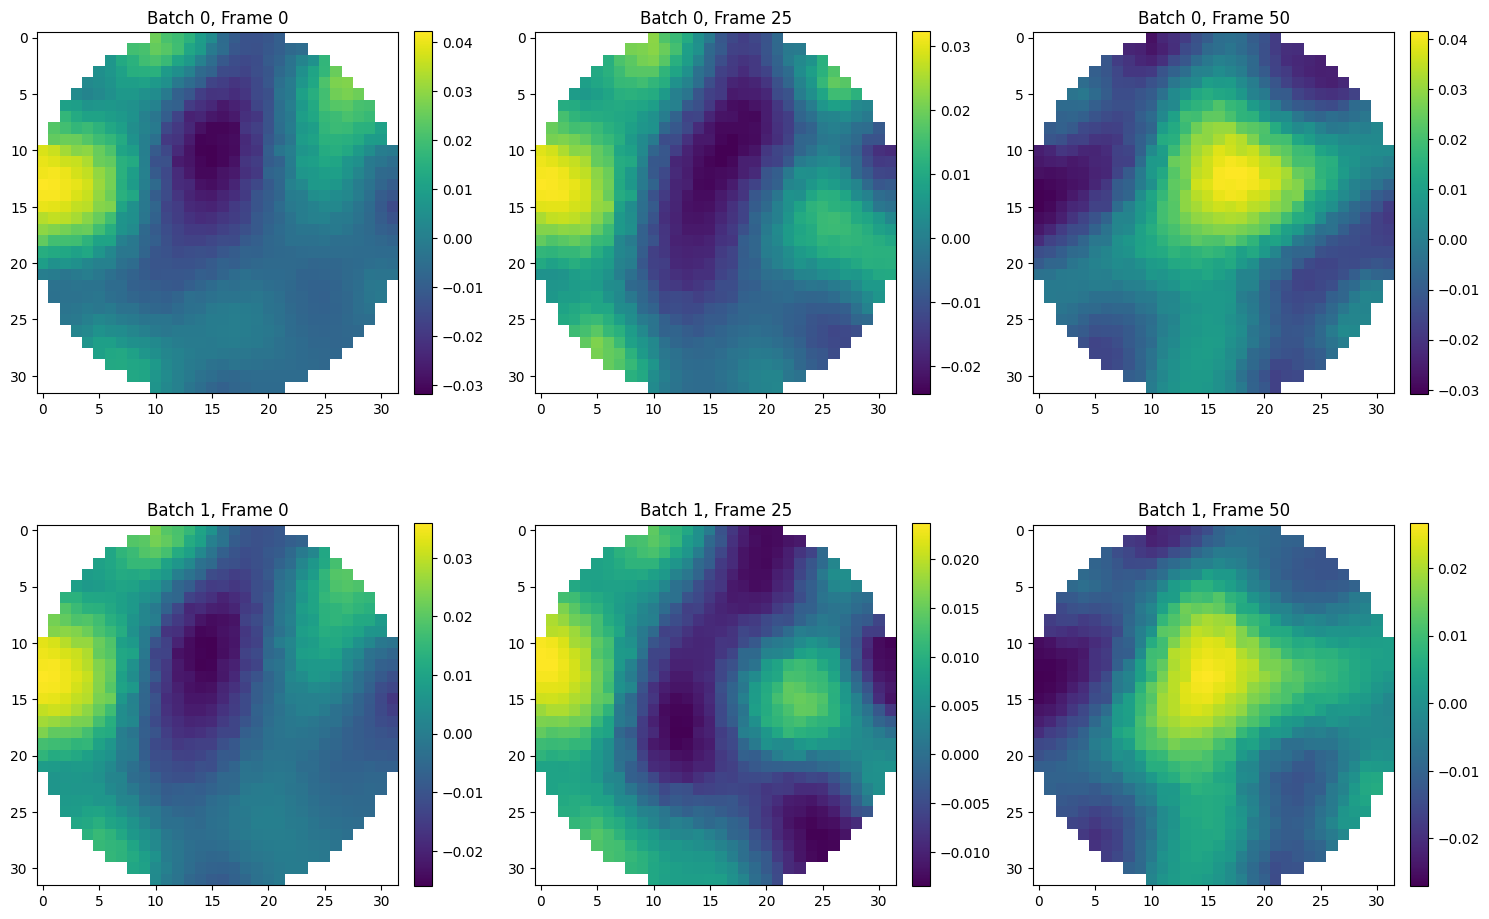

In [6]:
# Quick custom plots - modify these as needed

# Plot different frames from different batches
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

frame_examples = [
    (0, 0),   # batch 0, frame 0
    (0, 25),  # batch 0, frame 25
    (0, 50),  # batch 0, frame 50
    (1, 0),   # batch 1, frame 0
    (1, 25),  # batch 1, frame 25
    (1, 50),  # batch 1, frame 50
]

for i, (batch_idx, frame_idx) in enumerate(frame_examples):
    if batch_idx < pvi_data.shape[0] and frame_idx < pvi_data.shape[3]:
        frame = pvi_data[batch_idx, :, :, frame_idx]
        im = axes[i].imshow(frame, cmap='viridis', aspect='equal')
        axes[i].set_title(f'Batch {batch_idx}, Frame {frame_idx}')
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
    else:
        axes[i].text(0.5, 0.5, 'No data', ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_xticks([])
        axes[i].set_yticks([])

plt.tight_layout()
plt.show()
